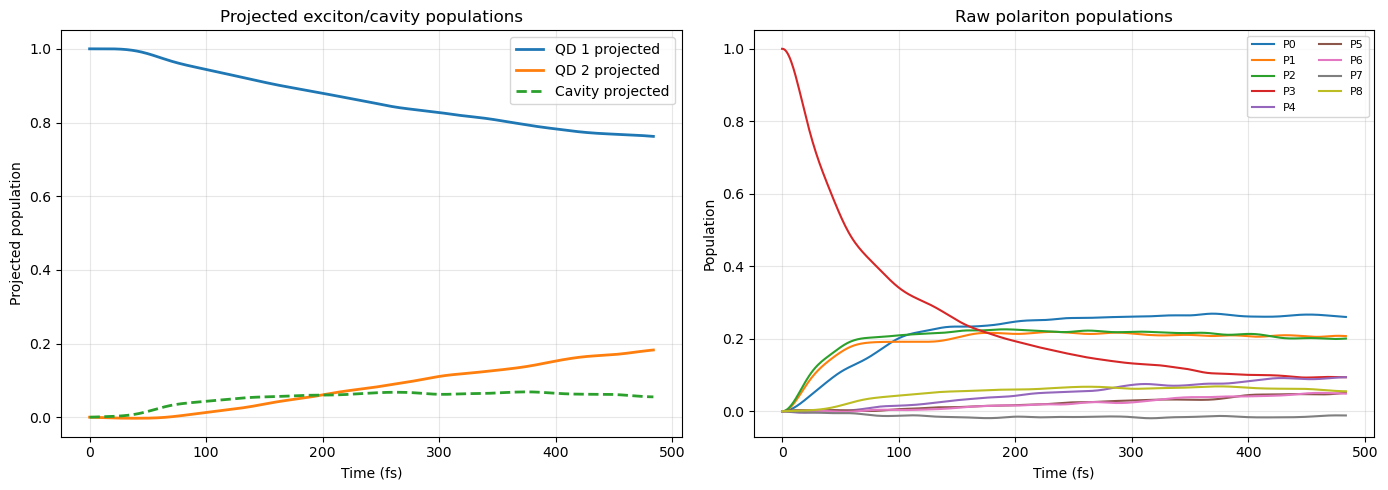

Max populations:
  QD 1: 1.00006
  QD 2: 0.182464
  Cavity: 0.0687506

Total population (should be ~1): 1


In [1]:
#!/usr/bin/env python3
"""
Read and plot population data from pop.out.

State ordering for this TC example:
- States 0-3: QD 1 exciton states
- States 4-7: QD 2 exciton states
- State 8: cavity photon state
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 2
nstate_per_qd = 4
n_cavity = 1
n_qd_states = n_qd * nstate_per_qd

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]
n_states = populations.shape[1]

if n_states != n_qd_states + n_cavity:
    raise ValueError(f"Expected {n_qd_states + n_cavity} states, found {n_states}")

# Extract QD and cavity populations
qd_pop = populations[:, :n_qd_states]
cavity_pop = populations[:, n_qd_states:]

# Sum population for each QD (across its nstate_per_qd states)
qd_total_pop = np.zeros((len(time), n_qd))
for qd in range(n_qd):
    start_idx = qd * nstate_per_qd
    end_idx = (qd + 1) * nstate_per_qd
    qd_total_pop[:, qd] = qd_pop[:, start_idx:end_idx].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot total population for each QD
ax = axes[0]
for qd in range(n_qd):
    ax.plot(time, qd_total_pop[:, qd], label=f"QD {qd + 1} projected", linewidth=2)
ax.plot(time, cavity_pop, label="Cavity projected", linewidth=2, linestyle="--")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Projected population")
ax.set_title("Projected exciton/cavity populations")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for state in range(n_states):
    ax.plot(time, populations[:, state], label=f"P{state}")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Population")
ax.set_title("Raw polariton populations")
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Max populations:")
for qd in range(n_qd):
    print(f"  QD {qd + 1}: {qd_total_pop[:, qd].max():.6g}")
print(f"  Cavity: {cavity_pop[:, 0].max():.6g}")
print(f"\nTotal population (should be ~1): {(qd_total_pop.sum(axis=1) + cavity_pop.sum(axis=1)).mean():.6g}")


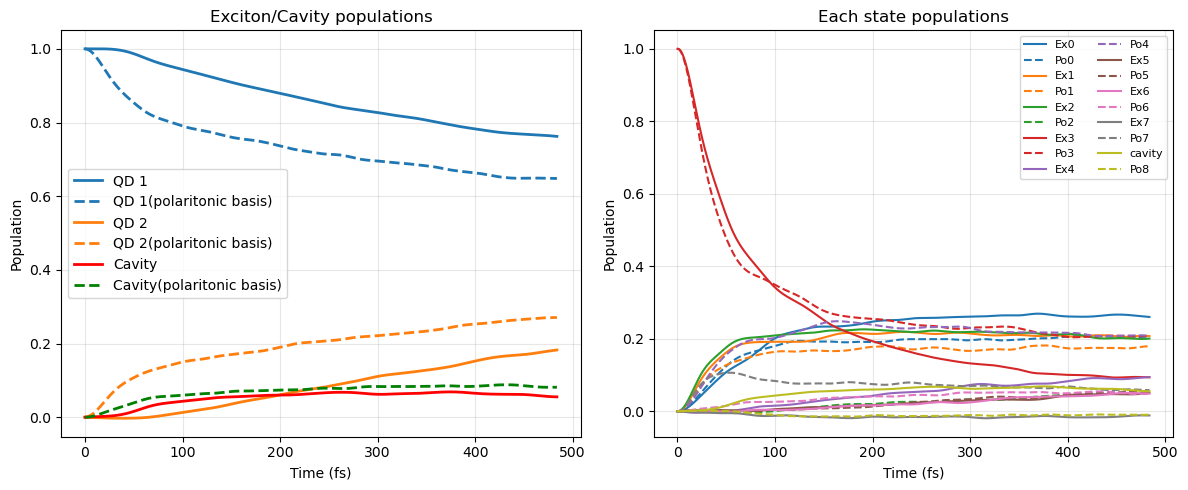

Max populations:
  QD 1: 1.00006
  QD 2: 0.182464
  Cavity: 0.0687506

Total population (should be ~1): 1


In [8]:
#!/usr/bin/env python3
"""
Read and plot population data from pop.out.

State ordering for this TC example:
- States 0-3: QD 1 exciton states
- States 4-7: QD 2 exciton states
- State 8: cavity photon state
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 2
nstate_per_qd = 4
n_cavity = 1
n_qd_states = n_qd * nstate_per_qd

data = np.loadtxt("pop.out")
data_po=np.loadtxt("../TEST_2QD_po_in_lvc/pop.out")

time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]


time_po = data_po[:, 0] * autos * 1e15  # au to fs
populations_po = data_po[:, 1:]
n_states = populations_po.shape[1]
transform = np.load("../TEST_2QD_po_in_lvc/polariton_transform_AU.npz")
U = transform["exciton_to_polariton_U"]
polariton_energies_AU = transform["polariton_energies_AU"]
exciton_projected_pop = populations_po @ (np.abs(U) ** 2).T


n_states = populations.shape[1]
n_states_po = populations_po.shape[1]

if n_states != n_qd_states + n_cavity:
    raise ValueError(f"Expected {n_qd_states + n_cavity} states, found {n_states}")

# Extract QD and cavity populations
qd_pop = populations[:, :n_qd_states]
cavity_pop = populations[:, n_qd_states:]
qd_pop_projected = exciton_projected_pop[:, :n_qd_states]
cavity_pop_projected = exciton_projected_pop[:, n_qd_states:]

# Sum population for each QD (across its nstate_per_qd states)
qd_total_pop = np.zeros((len(time), n_qd))
qd_total_pop_projected = np.zeros((len(time_po), n_qd))
for qd in range(n_qd):
    start_idx = qd * nstate_per_qd
    end_idx = (qd + 1) * nstate_per_qd
    qd_total_pop[:, qd] = qd_pop[:, start_idx:end_idx].sum(axis=1)
    qd_total_pop_projected[:, qd] = qd_pop_projected[:, start_idx:end_idx].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot total population for each QD
ax = axes[0]
for qd in range(n_qd):
    ax.plot(time, qd_total_pop[:, qd], label=f"QD {qd + 1}", linewidth=2,color="C%s"%qd)
    ax.plot(time_po, qd_total_pop_projected[:, qd], label=f"QD {qd + 1}(polaritonic basis)", linewidth=2,linestyle="--",color="C%s"%qd)
ax.plot(time, cavity_pop, label="Cavity", linewidth=2,color='red')
ax.plot(time_po, cavity_pop_projected, label="Cavity(polaritonic basis)", linewidth=2, linestyle="--",color='green')
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Population")
ax.set_title("Exciton/Cavity populations")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for state in range(n_states-1):
    ax.plot(time, populations[:, state], label=f"Ex{state}",color="C%s"%state)
    ax.plot(time_po, populations_po[:, state], label=f"Po{state}", linestyle="--",color="C%s"%state)
ax.plot(time, populations[:, n_states-1], label=f"cavity",color="C%s"%(n_states-1))
ax.plot(time_po, populations_po[:, n_states-1], label=f"Po{n_states-1}", linestyle="--",color="C%s"%(n_states-1))
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Population")
ax.set_title("Each state populations")
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Max populations:")
for qd in range(n_qd):
    print(f"  QD {qd + 1}: {qd_total_pop[:, qd].max():.6g}")
print(f"  Cavity: {cavity_pop[:, 0].max():.6g}")
print(f"\nTotal population (should be ~1): {(qd_total_pop.sum(axis=1) + cavity_pop.sum(axis=1)).mean():.6g}")
